# From p-GaAs to an emitted electron beam

This tutorial follows an electron ensemble through **photoexcitation → transport → surface emission**,
then examines the emitted beam with **openPMD-beamphysics `ParticleGroup` and its native plots**.
No additional beam-analysis package is needed.

You will learn to:

1. Choose the sample, light pulse, surface, and numerical parameters.
2. Run the simulation and interpret QE, spin polarization, energy, and MTE.
3. Inspect correlations and preserve the particle-by-particle spin and valley information.
4. Export an emission source for a vacuum-side simulation.
5. Add a finite laser spot and pulse, sampled with distgen.
6. Compare QE and ESP with **Chubenko et al., Fig. 18**, including the paper's simulation and experimental data.

The first example uses a semi-infinite sample. A finite-layer example is included as an optional exercise.
The Fig. 18 section has independent settings and can be run after the setup cell without running the first example.

## 1. Set up the environment

Open this notebook from the repository (or its `examples/` folder) and select your Python kernel.
The CPU workflow needs NumPy, SciPy, Matplotlib, `openpmd-beamphysics`, and Numba; the laser
section also needs distgen. Jupyter supplies the
notebook interface. For example, in the selected environment:

```text
python -m pip install numpy scipy matplotlib openpmd-beamphysics distgen numba jupyterlab
```

CUDA additionally needs a compatible NVIDIA GPU, CUDA runtime, CuPy, and Numba CUDA support.
The default `device="auto"` uses CUDA when available, otherwise compiled CPU execution.
The first compiled call takes additional time. This notebook uses ordinary inline plots, so it does
not need a widget backend. The import below supports both beamphysics package import names.

In [1]:
%matplotlib inline

import csv
import hashlib
import inspect
import json
import sys
from dataclasses import fields
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

root = Path.cwd().resolve()
while not (root / "gaas_mc").is_dir() and root != root.parent:
    root = root.parent
if not (root / "gaas_mc").is_dir():
    raise FileNotFoundError("Open this notebook from the GaAsTransport repository or examples folder.")
sys.path.insert(0, str(root))

try:
    from beamphysics import ParticleGroup
except ImportError:
    from pmd_beamphysics import ParticleGroup

from gaas_mc.emission import simulate_emission
from gaas_mc.constants import C_LIGHT, M0, PS, Q_E

out = root / "examples" / "out" / "particlegroup_tutorial"
out.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Repository:", root)
print("Outputs:", out)

Repository: C:\Users\acb20\OneDrive\Desktop\Claude\GaAsTransport
Outputs: C:\Users\acb20\OneDrive\Desktop\Claude\GaAsTransport\examples\out\particlegroup_tutorial


## 2. Choose all simulation parameters

The dictionary below shows **every argument accepted by `simulate_emission`**. Values are a useful
starting example, not universal material or gun settings. `n` is the number of **generated
photoelectrons**, and the number emitted is generally much smaller.

`chi_eV` is measured from the **local Gamma conduction edge at the surface**. Relative to the bulk
edge, the effective affinity is $\chi_{\mathrm{eff}}=\chi-E_{\mathrm{bb}}$; at
$p=10^{19}\,\mathrm{cm}^{-3}$, $E_{\mathrm{bb}}\simeq0.694$ eV, so $\chi=0.67$ eV gives
$\chi_{\mathrm{eff}}\simeq-0.024$ eV.

The excitation pulse is instantaneous at $t=0$. `t_max_ps` is a **hard cutoff**, not a pulse width
or an exponential recombination lifetime. Reducing it makes a run faster but excludes late emission.

In [2]:
params = dict(
    hv_eV=1.55,                  # Photon energy [eV]; must be allowed by excitation and absorption models.
    p_cm3=1.0e19,                # Acceptor/hole density [cm^-3].
    chi_eV=0.67,                 # Local surface affinity [eV]; chi_eff = chi - band-bending depth.
    n=100_000,                   # Generated electrons (C21 ensemble size); fewer runs faster but noisier.
    t_max_ps=370.0,              # Stop transport at this time [ps]; C21 benchmark uses 370 ps.
    thickness_nm=None,           # None = semi-infinite; e.g. 200.0 gives a 200 nm GaAs layer.
    R_back=0.0,                  # Back reflection probability [0,1]; used only for a finite layer.
    depletion_scattering="bulk", # "bulk" = C21 baseline; "local" = depleted holes/local screening.
    matching_mass="band_edge",   # Interface mass: "band_edge" (C21 default) or "velocity".
    absorption_model=None,      # None or "casey1975+adachi1989" = blended default;
                                # "casey1975" = near-edge data only; "adachi1989" = C21.
                                # Also accepts a constant absorption length [m], a callable
                                # photon energy [J] -> length [m], or a model object with
                                # absorption_coefficient(energy_J) -> alpha [1/m].
    device="auto",              # "auto", "cuda", "cpu" (compiled), or "reference" (NumPy).
    seed=1,                     # Random seed; reproducible for the same setup and engine.
    sigma_xy=0.0,               # Added Gaussian laser-spot rms per axis [m]; 0 = point excitation.
    total_charge=None,          # Emitted bunch charge [C]; None gives charge +e per macroparticle.
)

# Catch documentation drift if the driver later gains or removes a parameter.
assert set(params) == set(inspect.signature(simulate_emission).parameters)

`sigma_xy` adds a Gaussian excitation spot to the **lateral displacement accumulated in GaAs**.
At zero spot size, the resulting x/y spread is transport alone. `total_charge` rescales output
macroparticle weights; it does not alter transport or QE. ParticleGroup stores positive charge
weights for electron macroparticles and identifies the species separately.

The driver uses bulk depletion scattering by default; the lower-level `ModelAssumptions()` default
is local. Choose explicitly when comparing results. The reference engine is useful for small checks,
but the compiled engines are more practical for these ensemble sizes.

In [3]:
started = perf_counter()
run = simulate_emission(**params)
pg = run.particle_group  # An ordinary ParticleGroup: no wrapper is needed.
em = run.emissions      # Extra records, in the same original particle order.

print(f"Engine: {run.settings['device']}; elapsed: {perf_counter() - started:.1f} s")
print(f"Generated: {run.n_generated:,}; emitted: {run.n_emitted:,}")
print(f"Absorbed fraction of incident photons: {run.absorbed_fraction:.4f}")
print(f"QE: {100 * run.qe:.3f}%; emitted ESP: {100 * run.esp:.2f}%")
display(pg)

Engine: cuda; elapsed: 57.5 s
Generated: 100,000; emitted: 7,959
Absorbed fraction of incident photons: 0.6799
QE: 5.411%; emitted ESP: 24.84%


<ParticleGroup with 7959 particles at 0x2656606c1a0>

## 3. Interpret the output and check its units

QE is emitted electrons per **incident photon**. The simulation samples generated electrons
conditional on absorption; `run.absorbed_fraction` accounts for optical reflection and finite-layer
absorption. Thus $\mathrm{QE}=A\,N_{\mathrm{emit}}/N_{\mathrm{generated}}$.
ESP is the average of the emitted $s=\pm1$ labels, not the initial polarization.

| Quantity | ParticleGroup | `run.emissions` |
|---|---|---|
| Momentum | `pg.px`, `pg.py`, `pg.pz` in eV/c | `em.p_vac` in kg m/s |
| Direction | Beam leaves along **+z** | Beam leaves along **−z** (simulation coordinates) |
| Time | `pg.t` in seconds | `em.t` in seconds |
| Energy | `pg.kinetic_energy` in eV | `em.E_vac`, `em.E_perp` in joules |
| Position | Metres; every `pg.z` is zero | `em.x`, `em.y`: lateral displacement before adding the laser spot |
| Spin/valley | Stored separately | `em.spin`; `em.valley`: 0=Gamma, 1=L, 2=X; `em.eqv`: equivalent valley |

The spin labels remain defined along the simulation's +z axis; reversing exported pz does not
redefine them as helicity. These particles are **emission events at different times**, not a bunch
advanced to a common observation time. Image-charge, space-charge, and DC gun fields are not included.

For these sub-eV electrons, the nonrelativistic relations are sufficient:
$K=(p_x^2+p_y^2+p_z^2)/(2m_e)$ and $\mathrm{MTE}=\langle(p_x^2+p_y^2)/(2m_e)\rangle$.
The package's native kinetic-energy accessor uses the relativistic expression; the tiny difference
from the simulation's nonrelativistic energy is expected.

In [4]:
rest_energy_eV = M0 * C_LIGHT**2 / Q_E
if len(pg):
    kinetic_eV = (pg.px**2 + pg.py**2 + pg.pz**2) / (2 * rest_energy_eV)
    transverse_eV = (pg.px**2 + pg.py**2) / (2 * rest_energy_eV)
    mte_eV = np.average(transverse_eV, weights=pg.weight)

    # Scale to eV and give an explicit tolerance; default SI tolerances would be misleading.
    np.testing.assert_allclose(kinetic_eV, em.E_vac / Q_E, rtol=1e-11, atol=1e-14)
    np.testing.assert_allclose(mte_eV, em.E_perp.mean() / Q_E, rtol=1e-11, atol=1e-14)
    assert np.all(pg.pz > 0) and np.all(pg.z == 0)
    np.testing.assert_array_equal(pg.id, em.pid + 1)

    print(f"Mean vacuum kinetic energy: {1e3 * np.average(kinetic_eV, weights=pg.weight):.2f} meV")
    print(f"MTE: {1e3 * mte_eV:.2f} meV")
    print(f"Rms x: {1e9 * pg['sigma_x']:.2f} nm")
    print("Emission-time percentiles (10, 50, 90%) [ps]:", np.round(np.percentile(pg.t / PS, [10, 50, 90]), 2))
    print(f"Exported total charge: {pg.charge:.4g} C")
else:
    print("No electrons emitted: QE is zero; beam moments and emitted ESP are undefined.")

Mean vacuum kinetic energy: 96.31 meV
MTE: 12.23 meV
Rms x: 417.33 nm
Emission-time percentiles (10, 50, 90%) [ps]: [  1.19  56.98 266.14]
Exported total charge: 1.275e-15 C


## 4. Use ParticleGroup's own plots

`pg.plot(key)` makes a one-dimensional density plot; `pg.plot(key1, key2)` makes a two-dimensional
plot with marginal distributions. The plotting methods choose convenient axis units automatically.
These plots use macroparticle charge weights. All emitted particles in this driver have equal weight.

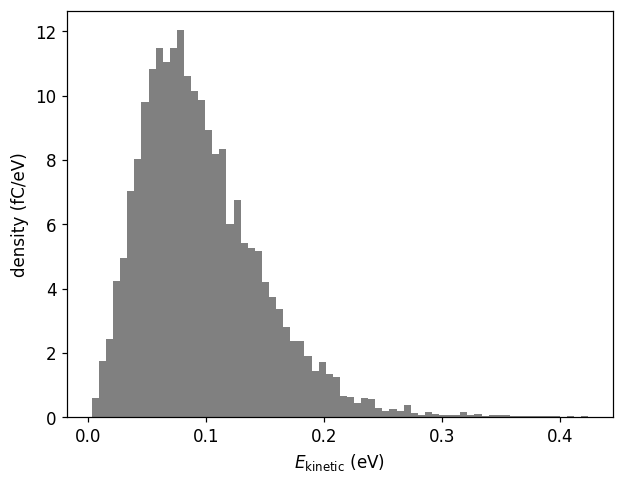

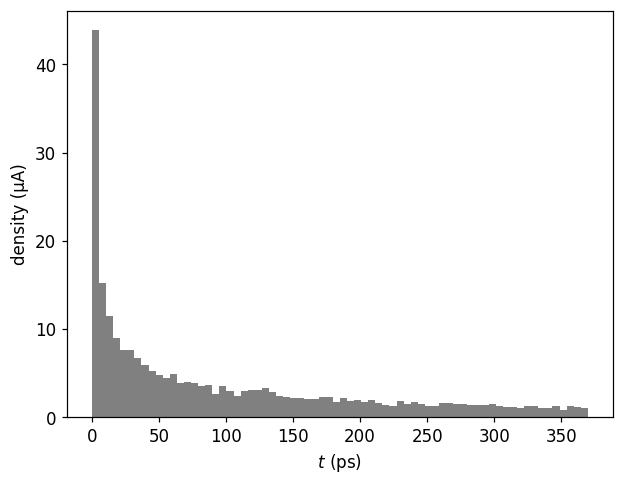

In [5]:
if len(pg):
    for key in ("kinetic_energy", "t"):
        fig = pg.plot(key, bins=70, return_figure=True)
        fig.savefig(out / f"beam_{key}.png", dpi=150, bbox_inches="tight")
        display(fig)
        plt.close(fig)

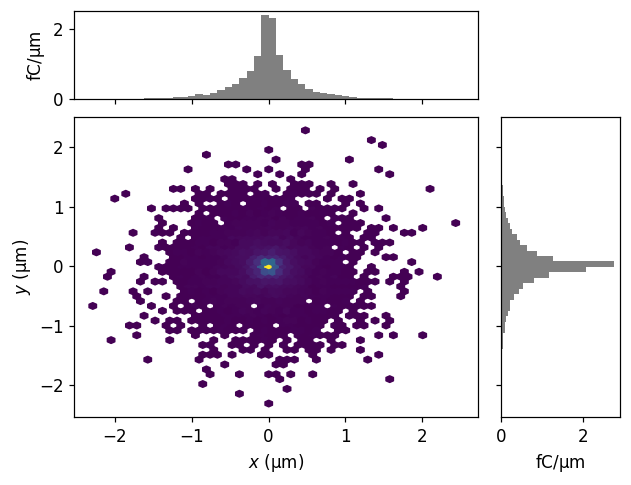

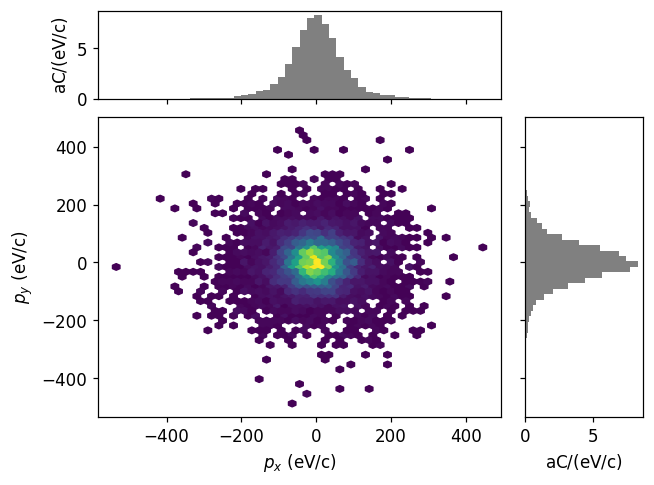

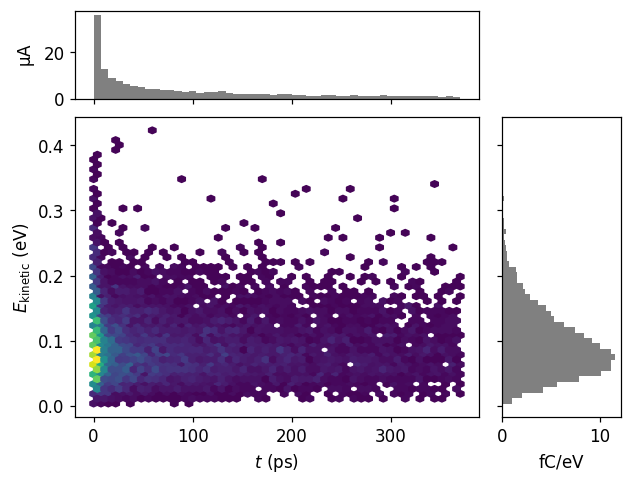

In [6]:
if len(pg):
    for key1, key2 in (("x", "y"), ("px", "py"), ("t", "kinetic_energy")):
        fig = pg.plot(key1, key2, bins=50, return_figure=True)
        fig.savefig(out / f"beam_{key1}_{key2}.png", dpi=150, bbox_inches="tight")
        display(fig)
        plt.close(fig)

## 5. Examine spin, valley, and timing together

Spin and valley are not standard ParticleGroup plot keys, so use their aligned records for this
analysis. A single ensemble ESP can hide differences between prompt and delayed emission.
The uncertainty bars below are one-standard-error estimates for independent ±1 spin samples;
very sparsely occupied bins are omitted. They do not include model uncertainty.

If you later select or reorder the beam, apply the same selection to these records, or join on
`pg.id == em.pid + 1`. The valley label is the valley **at emission**, not its full transport history.

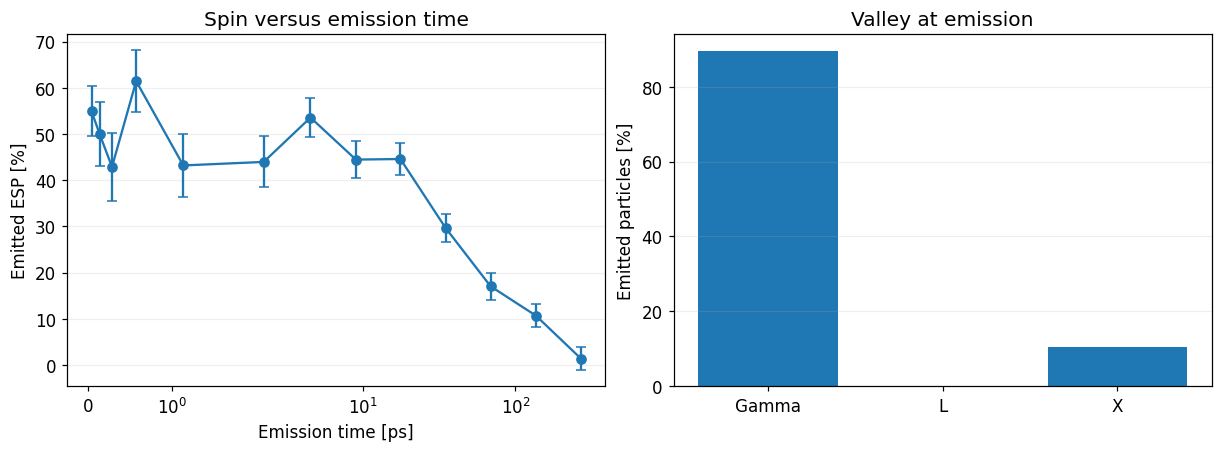

In [7]:
if len(pg):
    time_ps = em.t / PS
    edges = np.geomspace(0.1, max(params["t_max_ps"], 0.2), 13)
    edges = np.r_[0.0, edges]
    centres, polarization, uncertainty = [], [], []
    for low, high in zip(edges[:-1], edges[1:]):
        select = (time_ps >= low) & (time_ps < high)
        spins = em.spin[select].astype(float)
        if spins.size >= 10:
            centres.append(time_ps[select].mean())
            polarization.append(spins.mean())
            uncertainty.append(np.sqrt((1 - spins.mean()**2) / spins.size))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
    axes[0].errorbar(centres, 100 * np.array(polarization), 100 * np.array(uncertainty), fmt="o-", capsize=3)
    axes[0].set(xscale="symlog", xlabel="Emission time [ps]", ylabel="Emitted ESP [%]", title="Spin versus emission time")
    counts = np.bincount(em.valley, minlength=3)
    axes[1].bar(["Gamma", "L", "X"], 100 * counts / len(em))
    axes[1].set(ylabel="Emitted particles [%]", title="Valley at emission")
    for ax in axes:
        ax.grid(alpha=0.2, axis="y")
    fig.savefig(out / "spin_and_valley.png", dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

## 6. Try a finite GaAs layer (optional)

A finite layer occupies $0<z<d$. At the back, the electron reflects specularly with probability
`R_back`, otherwise it is lost to the substrate. Generation uses the truncated Beer–Lambert depth
distribution, and the absorbed fraction of incident photons includes the finite layer thickness.
This simple model does not include substrate transport or optical interference. Very thin layers
also challenge the assumed semi-infinite front band-bending profile.

The settings below make this exercise reproducible without replacing the first beam. Set the
switch to `True` to run it. Compare QE and timing while changing `R_back` from 0 to 1.

In [8]:
RUN_FINITE_LAYER = False
film_params = dict(params, thickness_nm=200.0, R_back=0.5, seed=2)
if RUN_FINITE_LAYER:
    film_run = simulate_emission(**film_params)
    print(f"200 nm layer: QE={100 * film_run.qe:.3f}%, ESP={100 * film_run.esp:.2f}%")
    if film_run.n_emitted:
        film_run.particle_group.plot("t", bins=70)

## 7. Save the source, metadata, and settings

The HDF5 file contains the standard ParticleGroup beam fields. The companion NPZ stores all available
emission records, including spin, valley, and the semiconductor state, plus the matching ParticleGroup
IDs. It retains the simulation frame for `p_vac`; the HDF5 beam uses the outgoing +z convention.
The settings file records the driver arguments and the actual engine selected.

In [9]:
pg.write(str(out / "emitted_electrons.h5"))
emission_arrays = {f.name: getattr(em, f.name) for f in fields(em) if getattr(em, f.name) is not None}
np.savez_compressed(out / "emitted_records.npz", particle_group_id=em.pid + 1, **emission_arrays)

def json_setting(value):
    # Named/default models are JSON-native. For custom model objects, keep a readable description.
    return value if value is None or isinstance(value, (str, int, float, bool)) else repr(value)

saved_settings = dict(
    requested={k: json_setting(v) for k, v in params.items()},
    resolved={k: json_setting(v) for k, v in run.settings.items()},
    qe=run.qe, esp=run.esp if np.isfinite(run.esp) else None,
)
(out / "settings.json").write_text(json.dumps(saved_settings, indent=2), encoding="utf-8")

reloaded = ParticleGroup(h5=str(out / "emitted_electrons.h5"))
assert len(reloaded) == len(pg)
if len(pg):
    np.testing.assert_array_equal(reloaded.id, pg.id)
    np.testing.assert_allclose(reloaded.pz, pg.pz, rtol=1e-12, atol=0)
print("Saved and reloaded:", out / "emitted_electrons.h5")

Saved and reloaded: C:\Users\acb20\OneDrive\Desktop\Claude\GaAsTransport\examples\out\particlegroup_tutorial\emitted_electrons.h5


## 8. Add a laser pulse with distgen

The simulation above uses a point excitation at $t=0$, so its output is the cathode's **response**
to an instantaneous point source. The semiconductor is laterally uniform and responds linearly to the
light, so the beam produced by a finite laser pulse is that response convolved with the laser
distribution: each emitted electron is shifted by the position and time at which it was excited.

Here, distgen samples the excitation points. It generates one laser particle per emitted electron,
with Gaussian x, y, and t and zero momentum. Adding the two particle groups coordinate by coordinate
gives the final beam: $x = x_{\mathrm{laser}} + x_{\mathrm{GaAs}}$ and $t = t_{\mathrm{laser}} + t_{\mathrm{emit}}$.
Momenta come from the GaAs simulation because the laser momenta are zero.

The two ensembles are independent random samples, so pairing them row by row is a valid Monte Carlo
estimate of the convolution. Each emitted electron receives exactly one excitation point.
Macroparticle weights, and therefore the bunch charge, come from the GaAs simulation; distgen's
`total_charge` is needed only to make its input complete. The `start: free` option keeps the sampled
time distribution; distgen's `time` start would set every time to `tstart`.

In [10]:
# Point-source response: 100,000 generated electrons with no laser spot
# (the run from section 2 is reused when its settings match).
mc_params = dict(params, n=100_000, sigma_xy=0.0)
mc_run = run if mc_params == params else simulate_emission(**mc_params)
pg_mc = mc_run.particle_group
print(f"Generated: {mc_run.n_generated:,}; emitted: {mc_run.n_emitted:,}; "
      f"QE: {100 * mc_run.qe:.3f}%")

Generated: 100,000; emitted: 7,959; QE: 5.411%


In [11]:
from distgen import Generator

laser_yaml = '''
n_particle: 1000           # placeholder; set below to the number of emitted electrons
species: electron
total_charge:              # required by distgen; the final weights come from the GaAs simulation
  value: 1
  units: pC
random:
  type: pseudo             # independent pseudo-random draws (not an ordered Hammersley sequence)
  seed: 11
start:
  type: free               # keep the t distribution; "time" would fix all t to tstart
x_dist:
  type: gaussian
  sigma_x:
    value: 0.25
    units: mm
y_dist:
  type: gaussian
  sigma_y:
    value: 0.25
    units: mm
t_dist:
  type: gaussian
  sigma_t:
    value: 2.0
    units: ps
'''

gen = Generator(laser_yaml)
gen["n_particle"] = len(pg_mc)
gen.run()
pg_laser = gen.particles
display(pg_laser)

<ParticleGroup with 7959 particles at 0x26777515590>

In [12]:
# Sum the excitation point and the cathode response for each emitted electron.
pg_beam = ParticleGroup(data=dict(
    x=pg_laser.x + pg_mc.x,
    y=pg_laser.y + pg_mc.y,
    z=pg_laser.z + pg_mc.z,
    px=pg_laser.px + pg_mc.px,
    py=pg_laser.py + pg_mc.py,
    pz=pg_laser.pz + pg_mc.pz,
    t=pg_laser.t + pg_mc.t,
    status=pg_mc.status,
    weight=pg_mc.weight,
    species=pg_mc.species,
    id=pg_mc.id,
))
pg_beam.write(str(out / "laser_beam.h5"))

# Independent sums: variances add, apart from finite-sample covariance noise.
print("rms     GaAs response      laser     quadrature sum   final beam")
for key, unit, scale in (("x", "um", 1e6), ("y", "um", 1e6), ("t", "ps", 1e12)):
    a, b, c = (scale * p[f"sigma_{key}"] for p in (pg_mc, pg_laser, pg_beam))
    print(f"{key} [{unit}]  {a:13.4g}  {b:11.4g}  {np.hypot(a, b):15.4g}  {c:11.4g}")
display(pg_beam)

rms     GaAs response      laser     quadrature sum   final beam
x [um]         0.4173          250              250          250
y [um]         0.4148          250              250          250
t [ps]          101.7            2            101.7        101.7


<ParticleGroup with 7959 particles at 0x26777509ba0>

The final beam's transverse size is set almost entirely by the laser spot: the lateral spread from
transport in GaAs is below a micrometre. The time distribution is the laser's Gaussian convolved with the
cathode response, whose long tail of late emission persists.

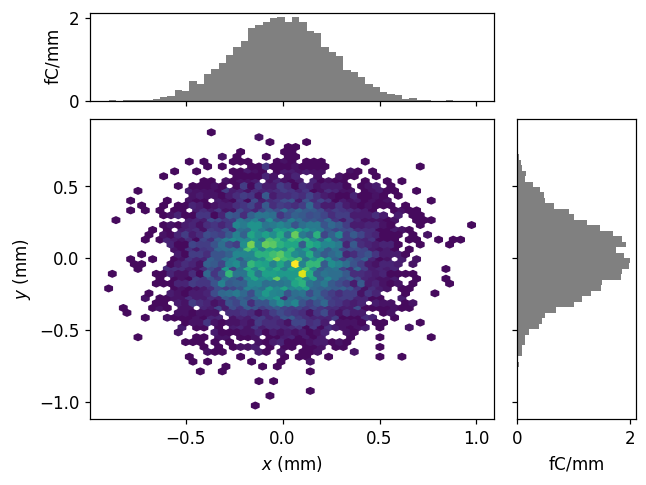

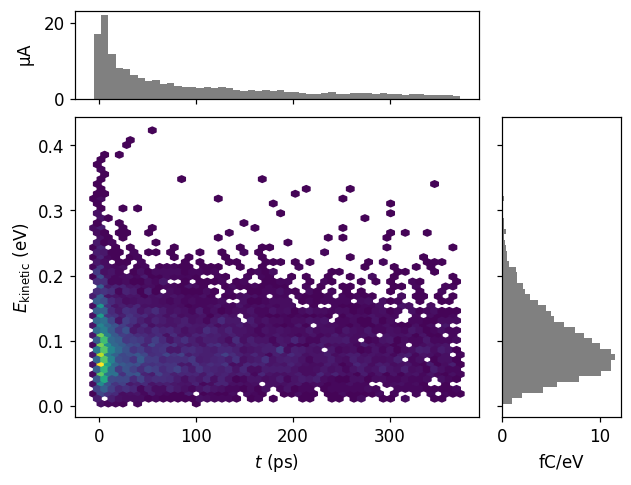

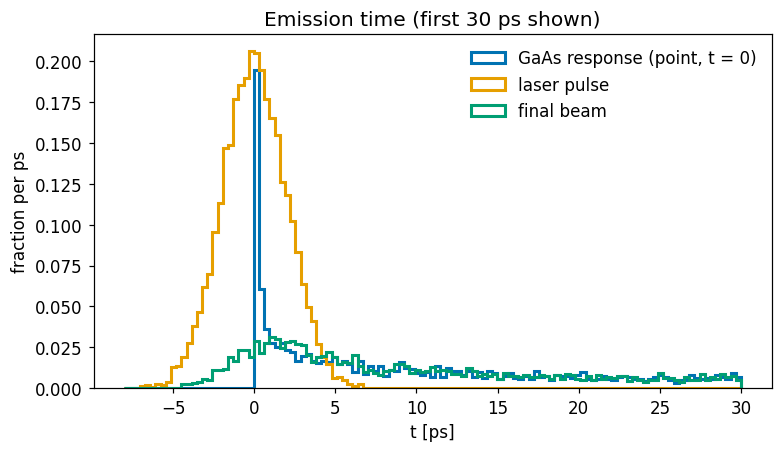

In [13]:
for key1, key2 in (("x", "y"), ("t", "kinetic_energy")):
    fig = pg_beam.plot(key1, key2, bins=50, return_figure=True)
    fig.savefig(out / f"laser_beam_{key1}_{key2}.png", dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

# Emission time: instantaneous-pulse response, laser pulse, and their convolution.
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
bins = np.linspace(-4 * 2.0, 30.0, 120)
for p, label, color in ((pg_mc, "GaAs response (point, t = 0)", "#0072B2"),
                        (pg_laser, "laser pulse", "#E69F00"),
                        (pg_beam, "final beam", "#009E73")):
    # Normalize to the whole ensemble, so the area outside the window (late emission) is not hidden.
    weight = np.full(len(p), 1 / (len(p) * (bins[1] - bins[0])))
    ax.hist(p.t / PS, bins=bins, weights=weight, histtype="step", linewidth=2, color=color, label=label)
ax.set_xlabel("t [ps]")
ax.set_ylabel("fraction per ps")
ax.set_title("Emission time (first 30 ps shown)")
ax.legend(frameon=False)
fig.savefig(out / "laser_beam_time.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

## 9. Reproduce the QE and ESP trends in Chubenko Fig. 18

**Source:** O. Chubenko et al., *Monte Carlo modeling of spin-polarized photoemission from p-doped
bulk GaAs*, J. Appl. Phys. **130**, 063101 (2021), [DOI: 10.1063/5.0060151](https://doi.org/10.1063/5.0060151).

We use the repository's `validation/reference/c21_fig18.csv`. Its header records extraction from
the accepted manuscript's vector graphics by `tools/extract_c21_fig18.py`. It contains both the
**published C21 simulation curves** and the **experimental points plotted in that figure**
(Liu 2017 and Chubenko 2014). These are digitized figure data, not the original experimental files;
the CSV does not supply experimental error bars.

The comparison fixes p=1e19 cm⁻³, a semi-infinite layer, 370 ps, bulk depletion scattering,
Adachi absorption, and the band-edge interface mass. We vary the photon energy and all four
surface affinities, chi=0.64/0.67/0.70/0.73 eV. This package intentionally retains FD hole blocking
and the corrected intervalley DOS factor; the goal is a benchmark comparison, not bit-for-bit
reproduction of the authors' code. A remaining ESP discrepancy at chi=0.73 eV is documented in
[Validation](../docs/VALIDATION.md) and the [audit and response](../docs/PHYSICS_AUDIT.md).

**Choose a budget:** the default, `quick` with `FIG18_N = 50_000`, runs five photon energies and four
affinities (20 runs), about 7 minutes on a recent NVIDIA GPU; the figures saved in this notebook come
from that setting. `paper_grid` runs all 16 energies; with `FIG18_N = 100_000`, the paper's ensemble
size, that takes about 45 minutes on the GPU. The compiled CPU engine is several times slower; lower
`FIG18_N` there for a first look. This straightforward tutorial reruns
transport for each affinity; the production script `validation/stage_e_fig18.py` reuses first-arrival
ensembles across surface branches and is more efficient for large sweeps.

In [14]:
reference_file = root / "validation" / "reference" / "c21_fig18.csv"
with reference_file.open(encoding="utf-8") as handle:
    paper = list(csv.DictReader(line for line in handle if not line.startswith("#")))

def paper_curve(source, quantity, chi=None):
    selected = [r for r in paper if r["source"] == source and r["quantity"] == quantity
                and (chi is None or (r["chi_eV"] and np.isclose(float(r["chi_eV"]), chi)))]
    return np.array(sorted((float(r["hv_eV"]), float(r["value_percent"])) for r in selected))

print(f"Loaded {len(paper)} digitized records from {reference_file.name}")
print("Sources:", ", ".join(sorted({r['source'] for r in paper})))

FIG18_MODE = "quick"  # "quick": 5 energies; "paper_grid": 16 energies, 1.45–2.20 eV in 0.05 eV steps.
FIG18_N = 50_000     # Generated electrons per (photon energy, affinity); C21 used 100_000.
FIG18_DEVICE = "auto" # "auto", "cuda", "cpu", or "reference"; compiled engines are recommended here.
USE_CACHE = True     # Reuse matching results; set False to rerun the selected points.

if FIG18_MODE not in ("quick", "paper_grid"):
    raise ValueError("FIG18_MODE must be 'quick' or 'paper_grid'")
photon_energies = (np.array([1.45, 1.60, 1.80, 2.00, 2.20]) if FIG18_MODE == "quick"
                   else np.round(np.arange(1.45, 2.2001, 0.05), 2))
affinities = (0.64, 0.67, 0.70, 0.73)

# Explicit, independent benchmark settings: edits to the earlier example cannot change this setup.
fig18_base = dict(
    p_cm3=1e19, n=FIG18_N, t_max_ps=370.0,
    thickness_nm=None, R_back=0.0,
    depletion_scattering="bulk", matching_mass="band_edge", absorption_model="adachi1989",
    device=FIG18_DEVICE, sigma_xy=0.0, total_charge=None,
)
print(f"{FIG18_MODE}: {len(photon_energies) * len(affinities)} runs of {FIG18_N:,} generated electrons")

Loaded 195 digitized records from c21_fig18.csv
Sources: C21_simulation, Chubenko2014_experiment, Liu2017_experiment
quick: 20 runs of 50,000 generated electrons


Each point is saved separately, so an interrupted sweep can resume. Cache keys include all input
settings and a hash of the local model source/data, avoiding accidental reuse after a code change.
The cache records the engine actually used. Delete this tutorial's `fig18_cache` directory or set
`USE_CACHE=False` when changing the Python/CUDA environment, which is not fully encoded in that hash.

The QE error estimate is $A\sqrt{f(1-f)/N}$ with $f=N_{\mathrm{emit}}/N$; the ESP estimate is
$\sqrt{(1-\mathrm{ESP}^2)/N_{\mathrm{emit}}}$. These are approximate sampling errors, not physical
model uncertainties. Empty emission samples have undefined ESP and are omitted from its plot.

In [15]:
cache_dir = out / "fig18_cache"
cache_dir.mkdir(exist_ok=True)
hasher = hashlib.sha256()
for source_file in sorted((root / "gaas_mc").rglob("*")):
    if source_file.suffix in (".py", ".csv"):
        hasher.update(source_file.relative_to(root).as_posix().encode())
        hasher.update(source_file.read_bytes())
model_hash = hasher.hexdigest()

fig18_rows = []
started = perf_counter()
for hv in photon_energies:
    for chi in affinities:
        settings = dict(fig18_base, hv_eV=float(hv), chi_eV=chi,
                        seed=180_000 + int(round(hv * 1000)) * 100 + int(round(chi * 100)))
        cache_input = dict(schema=1, model_hash=model_hash, settings=settings)
        key = hashlib.sha256(json.dumps(cache_input, sort_keys=True).encode()).hexdigest()[:20]
        cache_file = cache_dir / f"hv{hv:.2f}_chi{chi:.2f}_{key}.json"
        cached = USE_CACHE and cache_file.exists()
        if cached:
            record = json.loads(cache_file.read_text(encoding="utf-8"))
            assert record["input"] == cache_input
            row = record["summary"]
        else:
            point = simulate_emission(**settings)
            n_emit = point.n_emitted
            fraction = n_emit / point.n_generated
            row = dict(
                hv_eV=float(hv), chi_eV=chi, n=point.n_generated, n_emit=n_emit,
                qe=point.qe,
                qe_se=point.absorbed_fraction * np.sqrt(fraction * (1 - fraction) / point.n_generated),
                esp=point.esp if n_emit else None,
                esp_se=float(np.sqrt(max(0.0, 1 - point.esp**2) / n_emit)) if n_emit else None,
                device=point.settings["device"],
            )
            cache_file.write_text(json.dumps(dict(input=cache_input, summary=row), indent=2), encoding="utf-8")
        fig18_rows.append(row)
        print(f"hv={hv:.2f}, chi={chi:.2f}: QE={100 * row['qe']:.2f}% "
              f"({row['n_emit']} emitted, {row['device']}, {'cached' if cached else 'new'})", flush=True)

(out / "fig18_summary.json").write_text(json.dumps(fig18_rows, indent=2), encoding="utf-8")
print(f"Sweep elapsed: {perf_counter() - started:.1f} s")

hv=1.45, chi=0.64: QE=6.12% (4494 emitted, cuda, new)


hv=1.45, chi=0.67: QE=4.86% (3568 emitted, cuda, new)


hv=1.45, chi=0.70: QE=3.14% (2304 emitted, cuda, new)


hv=1.45, chi=0.73: QE=1.67% (1227 emitted, cuda, new)


hv=1.60, chi=0.64: QE=8.89% (6549 emitted, cuda, new)


...

hv=2.20, chi=0.64: QE=14.25% (10904 emitted, cuda, new)


hv=2.20, chi=0.67: QE=11.63% (8897 emitted, cuda, new)


hv=2.20, chi=0.70: QE=8.80% (6734 emitted, cuda, new)


hv=2.20, chi=0.73: QE=6.02% (4610 emitted, cuda, new)


Sweep elapsed: 429.3 s


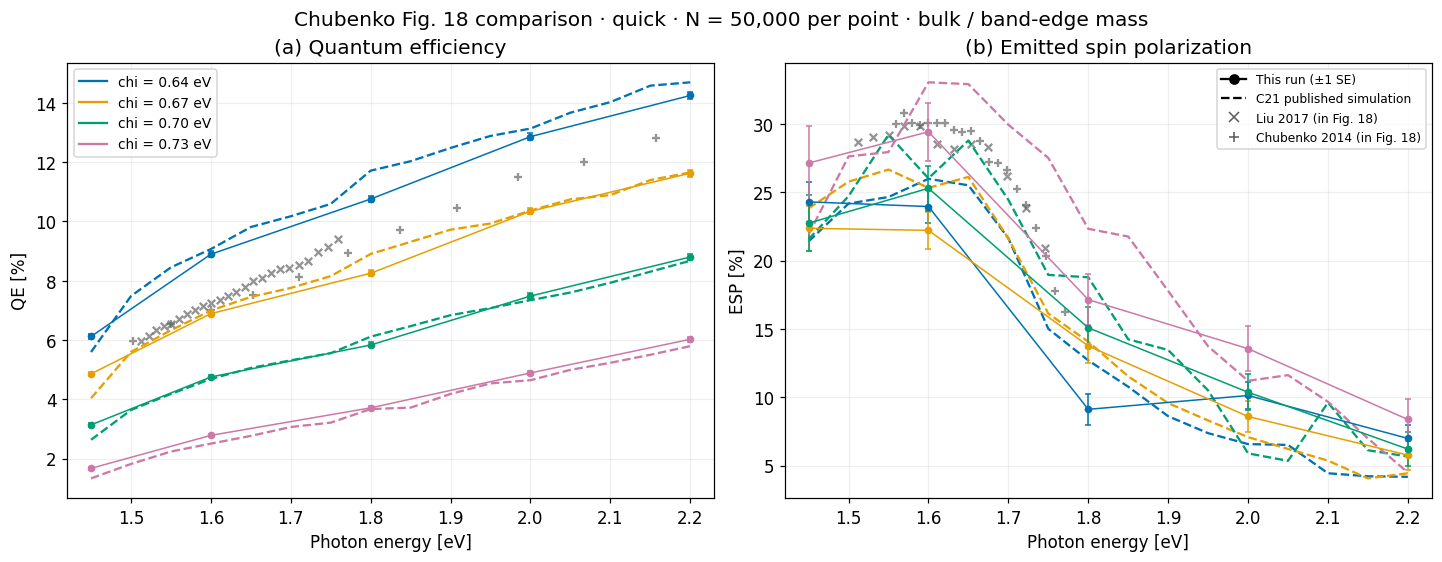

In [16]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
colors = ("#0072B2", "#E69F00", "#009E73", "#CC79A7")
for ax, quantity, key, error_key in zip(axes, ("QE", "ESP"), ("qe", "esp"), ("qe_se", "esp_se")):
    for chi, color in zip(affinities, colors):
        ref = paper_curve("C21_simulation", quantity, chi)
        ax.plot(ref[:, 0], ref[:, 1], "--", color=color, lw=1.5)
        rows = [r for r in fig18_rows if r["chi_eV"] == chi and r[key] is not None]
        ax.errorbar([r["hv_eV"] for r in rows], [100 * r[key] for r in rows],
                    yerr=[100 * r[error_key] for r in rows], color=color, fmt="o-", ms=4, lw=1, capsize=2)
    for source, marker in (("Liu2017_experiment", "x"), ("Chubenko2014_experiment", "+")):
        ref = paper_curve(source, quantity)
        if ref.size:
            ax.scatter(ref[:, 0], ref[:, 1], marker=marker, color="0.35", s=24, alpha=0.65, zorder=1)
    ax.set(xlabel="Photon energy [eV]", ylabel=f"{quantity} [%]", xlim=(1.42, 2.23))
    ax.grid(alpha=0.2)

axes[0].set_title("(a) Quantum efficiency")
axes[1].set_title("(b) Emitted spin polarization")
chi_handles = [Line2D([], [], color=color, label=f"chi = {chi:.2f} eV") for chi, color in zip(affinities, colors)]
axes[0].legend(handles=chi_handles, loc="upper left", fontsize=9)
style_handles = [Line2D([], [], color="black", marker="o", label="This run (±1 SE)"),
                 Line2D([], [], color="black", ls="--", label="C21 published simulation"),
                 Line2D([], [], color="0.35", ls="none", marker="x", label="Liu 2017 (in Fig. 18)"),
                 Line2D([], [], color="0.35", ls="none", marker="+", label="Chubenko 2014 (in Fig. 18)")]
axes[1].legend(handles=style_handles, loc="upper right", fontsize=8)
fig.suptitle(f"Chubenko Fig. 18 comparison · {FIG18_MODE} · N = {FIG18_N:,} per point · bulk / band-edge mass")
fig.savefig(out / "fig18_comparison.png", dpi=180, bbox_inches="tight")
display(fig)
plt.close(fig)

### Read the agreement quantitatively

Compare to the **C21 simulation curves**, not a fit to the experimental points. The table reports
the mean QE ratio and mean ESP difference over this notebook's sampled photon energies. With
only five energies and statistical errors of 1–3 percentage points in ESP per point, these
averages are indicative rather than precise. Uncertainties in the
original model and digitization are not included in the Monte Carlo error bars.

In [17]:
print("chi [eV]  mean QE / C21  mean ESP - C21 [percentage points]")
for chi in affinities:
    rows = [r for r in fig18_rows if r["chi_eV"] == chi]
    hv = np.array([r["hv_eV"] for r in rows])
    qe_ref = paper_curve("C21_simulation", "QE", chi)
    esp_ref = paper_curve("C21_simulation", "ESP", chi)
    qe_ratio = 100 * np.array([r["qe"] for r in rows]) / np.interp(hv, qe_ref[:, 0], qe_ref[:, 1])
    esp_pct = np.array([np.nan if r["esp"] is None else 100 * r["esp"] for r in rows])
    difference = esp_pct - np.interp(hv, esp_ref[:, 0], esp_ref[:, 1])
    mean_difference = np.nanmean(difference) if np.isfinite(difference).any() else np.nan
    print(f"{chi:8.2f}  {qe_ratio.mean():13.3f}  {mean_difference:+38.2f}")

chi [eV]  mean QE / C21  mean ESP - C21 [percentage points]
    0.64          0.988                                   +0.73
    0.67          1.022                                   -0.41
    0.70          1.039                                   +0.35
    0.73          1.094                                   +0.53
